In [1]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn

In [3]:
import pandas as pd

file_name = "student_assignment_10_cases.xlsx"

# Load correct sheet
df = pd.read_excel(file_name, sheet_name="Assignment_Cases")

# Clean column names
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset shape: (10, 3)
Columns: ['Case ID', 'Paraphrased Dialogue', 'Risk Level']


,Case ID,Paraphrased Dialogue,Risk Level
0,1,User: Everything is just too much right now. I...,attempt
1,2,User: I have nothing left to stay for. I’ve fe...,attempt
2,3,User: Time doesn't feel real anymore. I have n...,behavior
3,4,User: I think I’m nearing the end of the road....,behavior
4,5,User: Just make it stop. Please. I just want t...,ideation


In [4]:
print("Available columns:")
for i, col in enumerate(df.columns):
    print(i, col)

Available columns:
0 Case ID
1 Paraphrased Dialogue
2 Risk Level


In [5]:
# Rename columns (clean names)
df = df.rename(columns={
    "Case ID": "case_id",
    "Paraphrased Dialogue": "text",
    "Risk Level": "true_label"
})

# Clean labels
df["true_label"] = df["true_label"].astype(str).str.lower().str.strip()

# Check
df[["case_id", "text", "true_label"]].head()

,case_id,text,true_label
0,1,User: Everything is just too much right now. I...,attempt
1,2,User: I have nothing left to stay for. I’ve fe...,attempt
2,3,User: Time doesn't feel real anymore. I have n...,behavior
3,4,User: I think I’m nearing the end of the road....,behavior
4,5,User: Just make it stop. Please. I just want t...,ideation


In [6]:
def rule_based_classifier(text):
    text = str(text).lower()

    if any(k in text for k in ["kill myself", "end my life", "i'm done", "nothing left", "end of the road"]):
        return "attempt"
    elif any(k in text for k in ["no future", "disappear", "burden", "checked out"]):
        return "behavior"
    elif any(k in text for k in ["make it stop", "pain to end", "dark thoughts", "hopeless"]):
        return "ideation"
    elif any(k in text for k in ["overwhelmed", "failure", "anxiety", "exhausted"]):
        return "indicator"
    else:
        return "safe"

df["model_1"] = df["text"].apply(rule_based_classifier)

df[["case_id", "true_label", "model_1"]]

,case_id,true_label,model_1
0,1,attempt,ideation
1,2,attempt,attempt
2,3,behavior,behavior
3,4,behavior,attempt
4,5,ideation,behavior
5,6,ideation,safe
6,7,indicator,safe
7,8,indicator,behavior
8,9,safe,safe
9,10,safe,safe


In [7]:
def scoring_classifier(text):
    text = str(text).lower()

    scores = {
        "attempt": sum(word in text for word in ["done", "nothing left", "end of the road"]),
        "behavior": sum(word in text for word in ["no future", "burden", "disappear"]),
        "ideation": sum(word in text for word in ["make it stop", "pain", "hopeless"]),
        "indicator": sum(word in text for word in ["overwhelmed", "failure", "anxiety"]),
        "safe": 1
    }

    return max(scores, key=scores.get)

df["model_2"] = df["text"].apply(scoring_classifier)

df[["case_id", "true_label", "model_1", "model_2"]]

,case_id,true_label,model_1,model_2
0,1,attempt,ideation,ideation
1,2,attempt,attempt,attempt
2,3,behavior,behavior,behavior
3,4,behavior,attempt,indicator
4,5,ideation,behavior,ideation
5,6,ideation,safe,ideation
6,7,indicator,safe,ideation
7,8,indicator,behavior,attempt
8,9,safe,safe,safe
9,10,safe,safe,safe


In [8]:
from sklearn.metrics import accuracy_score, classification_report

acc1 = accuracy_score(df["true_label"], df["model_1"])
acc2 = accuracy_score(df["true_label"], df["model_2"])

print("Model 1 Accuracy:", acc1)
print("Model 2 Accuracy:", acc2)

print("\nMODEL 1 REPORT")
print(classification_report(df["true_label"], df["model_1"]))

print("\nMODEL 2 REPORT")
print(classification_report(df["true_label"], df["model_2"]))

print(classification_report(df["true_label"], df["model_1"], zero_division=0))
print(classification_report(df["true_label"], df["model_2"], zero_division=0))

Model 1 Accuracy: 0.4
Model 2 Accuracy: 0.6

MODEL 1 REPORT
              precision    recall  f1-score   support

     attempt       0.50      0.50      0.50         2
    behavior       0.33      0.50      0.40         2
    ideation       0.00      0.00      0.00         2
   indicator       0.00      0.00      0.00         2
        safe       0.50      1.00      0.67         2

    accuracy                           0.40        10
   macro avg       0.27      0.40      0.31        10
weighted avg       0.27      0.40      0.31        10


MODEL 2 REPORT
              precision    recall  f1-score   support

     attempt       0.50      0.50      0.50         2
    behavior       1.00      0.50      0.67         2
    ideation       0.50      1.00      0.67         2
   indicator       0.00      0.00      0.00         2
        safe       1.00      1.00      1.00         2

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.57        10
w

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


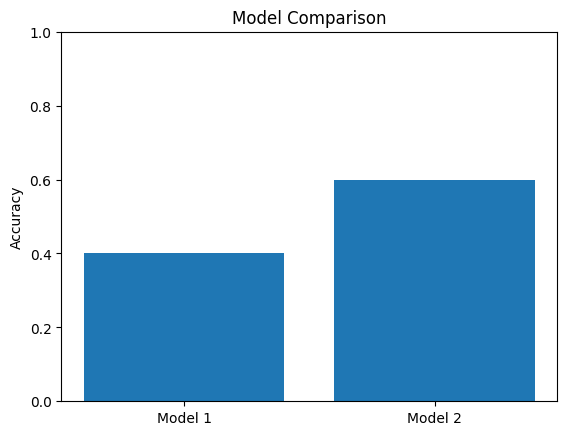

In [9]:
import matplotlib.pyplot as plt

models = ["Model 1", "Model 2"]
accuracies = [acc1, acc2]

plt.bar(models, accuracies)
plt.ylim(0,1)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [10]:
!pip install transformers torch

In [11]:
from transformers import pipeline

# Load model
classifier = pipeline("zero-shot-classification")

# Define labels
labels = ["attempt", "behavior", "ideation", "indicator", "safe"]

# Predict
def bert_classifier(text):
    result = classifier(text, labels)
    return result["labels"][0]

df["model_3"] = df["text"].apply(bert_classifier)

df[["case_id", "true_label", "model_1", "model_2", "model_3"]]

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,case_id,true_label,model_1,model_2,model_3
0,1,attempt,ideation,ideation,indicator
1,2,attempt,attempt,attempt,indicator
2,3,behavior,behavior,behavior,attempt
3,4,behavior,attempt,indicator,indicator
4,5,ideation,behavior,ideation,indicator
5,6,ideation,safe,ideation,indicator
6,7,indicator,safe,ideation,indicator
7,8,indicator,behavior,attempt,indicator
8,9,safe,safe,safe,indicator
9,10,safe,safe,safe,indicator


In [12]:
acc3 = accuracy_score(df["true_label"], df["model_3"])

print("Model 3 Accuracy:", acc3)

print("\nMODEL 3 REPORT")
print(classification_report(df["true_label"], df["model_3"], zero_division=0))

Model 3 Accuracy: 0.2

MODEL 3 REPORT
              precision    recall  f1-score   support

     attempt       0.00      0.00      0.00         2
    behavior       0.00      0.00      0.00         2
    ideation       0.00      0.00      0.00         2
   indicator       0.22      1.00      0.36         2
        safe       0.00      0.00      0.00         2

    accuracy                           0.20        10
   macro avg       0.04      0.20      0.07        10
weighted avg       0.04      0.20      0.07        10



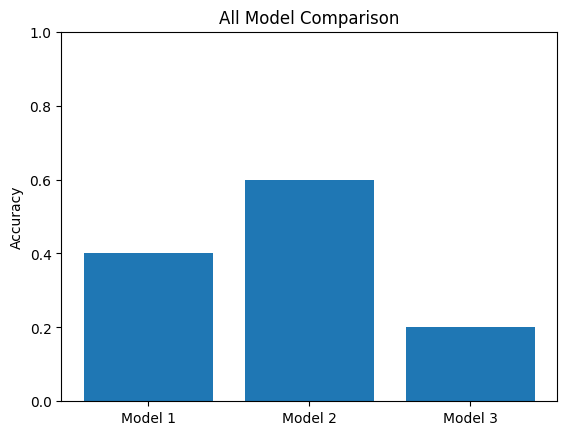

In [13]:
models = ["Model 1", "Model 2", "Model 3"]
accuracies = [acc1, acc2, acc3]

plt.bar(models, accuracies)
plt.ylim(0,1)
plt.title("All Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [14]:
# Final comparison table
final_results = pd.DataFrame({
    "Model": ["Model 1 - Rule-Based", "Model 2 - Keyword Scoring", "Model 3 - Zero-Shot Transformer"],
    "Accuracy": [acc1, acc2, acc3],
    "Comment": [
        "Simple baseline using fixed risk keywords",
        "Best performing model in this PoC",
        "Transformer model, but weak performance on small dataset"
    ]
})

final_results

,Model,Accuracy,Comment
0,Model 1 - Rule-Based,0.4,Simple baseline using fixed risk keywords
1,Model 2 - Keyword Scoring,0.6,Best performing model in this PoC
2,Model 3 - Zero-Shot Transformer,0.2,"Transformer model, but weak performance on sma..."


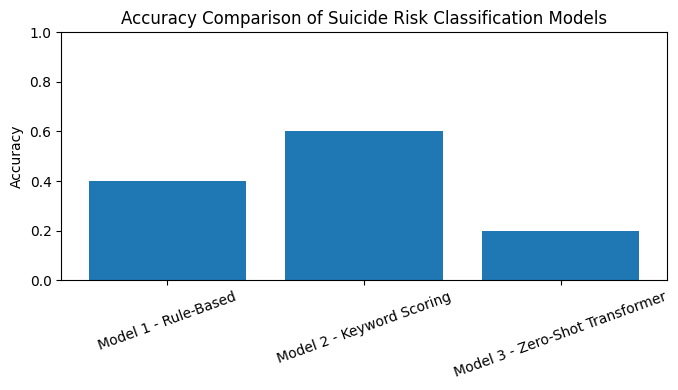

Saved files:
all_model_predictions.csv
final_model_accuracy_results.csv
model_accuracy_comparison.png


In [15]:
# Save outputs for report and submission evidence
df.to_csv("all_model_predictions.csv", index=False)
final_results.to_csv("final_model_accuracy_results.csv", index=False)

plt.figure(figsize=(7,4))
plt.bar(final_results["Model"], final_results["Accuracy"])
plt.ylim(0,1)
plt.title("Accuracy Comparison of Suicide Risk Classification Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("model_accuracy_comparison.png", dpi=300)
plt.show()

print("Saved files:")
print("all_model_predictions.csv")
print("final_model_accuracy_results.csv")
print("model_accuracy_comparison.png")

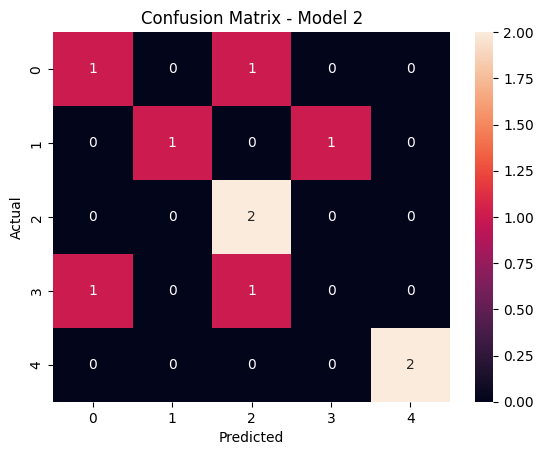

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(df["true_label"], df["model_2"])

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Model 2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()